<a href="https://colab.research.google.com/github/WVF-1/Computation-Budget/blob/main/gnn_scheduler_v1_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adaptive Computational Scheduling for GNNs — Version 1

Research framework validating a Thompson-Sampling-based computational scheduler
against a standard 2-layer GCN baseline on synthetic SBM data.

**Not production code.** Priorities: readability, modularity, simplicity.
Run cells top to bottom. The setup cell installs dependencies (only needs to
run once per Colab session).

## Setup

In [1]:
# Colab comes with torch preinstalled; torch_geometric needs an explicit install.
!pip install -q torch_geometric networkx scikit-learn matplotlib numpy scipy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.2 MB/s eta 0:00:00


In [2]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt

from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_networkx, k_hop_subgraph
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


## `data.py` — Synthetic SBM generation

In [3]:
def generate_sbm_graph(n_nodes=300, n_communities=3, p_intra=0.15, p_inter=0.02,
                       avg_degree=None, feature_dim=16, seed=None,
                       train_frac=0.6, val_frac=0.2):
    """
    Generate a synthetic Stochastic Block Model graph and convert it into a
    PyTorch Geometric Data object.

    Community labels become the classification targets. Node features are
    random Gaussian embeddings (placeholder input features for V0).

    Two SBM regimes are supported:

    - DENSE (default, avg_degree=None): p_intra/p_inter are used as fixed
      probabilities regardless of n_nodes. This is the classical/
      theoretical SBM convention (used e.g. for studying spectral phase
      transitions), but average node degree grows roughly linearly with
      n_nodes -- the graph gets denser as it gets bigger. This does NOT
      resemble most real-world graphs.

    - SPARSE (avg_degree=<number>): p_intra/p_inter are derived so that
      expected average node degree stays approximately constant as
      n_nodes grows, holding the same intra/inter ratio implied by the
      p_intra/p_inter arguments. This is the standard "sparse SBM" regime
      used to model realistic networks (citation graphs, social networks,
      molecular graphs), where edge count scales linearly with n rather
      than quadratically. Any technique that relies on a node's local
      neighborhood being small relative to the graph (e.g. subgraph-
      restricted computation in scheduler.py) implicitly assumes this
      regime -- it isn't meaningful on a densifying graph.

    train_frac / val_frac: fraction of nodes assigned to data.train_mask /
      data.val_mask; the remainder goes to data.test_mask. This is the
      standard transductive semi-supervised node classification setup
      (as in the original GCN paper's Planetoid experiments): every node
      and edge is visible to the model for message passing, but the loss
      is computed ONLY on train_mask nodes, and reported metrics are
      computed ONLY on test_mask nodes. Without this split (the V0
      default before this fix), "accuracy" measured in-sample training
      fit, not generalization -- a sufficiently deep model on an easy
      task could trivially reach 100% with no way to detect it.
    """
    rng = np.random.default_rng(seed)

    # Roughly equal-sized communities
    sizes = [n_nodes // n_communities] * n_communities
    sizes[-1] += n_nodes - sum(sizes)

    if avg_degree is not None:
        # Derive p_intra/p_inter that yield the target average degree,
        # preserving the ratio between the given p_intra and p_inter.
        ratio = p_inter / p_intra
        community_size = n_nodes / n_communities
        # expected_degree ~= (community_size - 1) * p_intra
        #                  + (n_nodes - community_size) * p_inter
        # substituting p_inter = ratio * p_intra and solving for p_intra:
        denom = (community_size - 1) + (n_nodes - community_size) * ratio
        p_intra = avg_degree / denom
        p_inter = ratio * p_intra

    # Probability matrix: p_intra on diagonal, p_inter off-diagonal
    probs = [[p_intra if i == j else p_inter for j in range(n_communities)]
             for i in range(n_communities)]

    G = nx.stochastic_block_model(sizes, probs, seed=seed)

    # Community label per node (networkx stores this in node attribute "block")
    labels = np.zeros(n_nodes, dtype=np.int64)
    for node, node_data in G.nodes(data=True):
        labels[node] = node_data["block"]

    data = from_networkx(G)
    data.y = torch.tensor(labels, dtype=torch.long)

    # Random node features h_i (placeholder embeddings for V0)
    data.x = torch.tensor(rng.normal(size=(n_nodes, feature_dim)), dtype=torch.float)

    # Train/val/test node masks (60/20/20 default). All nodes/edges stay
    # visible for message passing (transductive setting) -- only the loss
    # (train_mask) and the reported metrics (test_mask) are restricted.
    perm = rng.permutation(n_nodes)
    n_train = int(train_frac * n_nodes)
    n_val = int(val_frac * n_nodes)

    train_mask = torch.zeros(n_nodes, dtype=torch.bool)
    val_mask = torch.zeros(n_nodes, dtype=torch.bool)
    test_mask = torch.zeros(n_nodes, dtype=torch.bool)

    train_mask[torch.as_tensor(perm[:n_train])] = True
    val_mask[torch.as_tensor(perm[n_train:n_train + n_val])] = True
    test_mask[torch.as_tensor(perm[n_train + n_val:])] = True

    data.train_mask = train_mask
    data.val_mask = val_mask     # reserved for future use (e.g. early stopping); unused in V0
    data.test_mask = test_mask

    return data


## `model.py` — Standard 2-layer GCN + GAT-style attention scorer

In [4]:
class GCN(nn.Module):
    """
    Shallow 2-layer GCN backbone. This is now the DEFAULT-cost path for
    the scheduled model (ScheduledGCN inherits from this), not the
    experimental control -- that role has moved to DeepGCN below.
    """

    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        # cached=True: the graph structure (edge_index) never changes across
        # epochs within a run, so GCNConv can reuse its normalized adjacency
        # (self-loops + symmetric degree normalization) instead of
        # recomputing it from scratch on every forward call. This is a
        # correctness-neutral speedup for BOTH the baseline and scheduled
        # models -- it applies equally to conv1/conv2 in each, so it
        # doesn't change the comparison, just removes wasted repeat work
        # on both sides. A fresh model instance is created per run, so the
        # cache never goes stale across different graphs/seeds.
        self.conv1 = GCNConv(in_dim, hidden_dim, cached=True)
        self.conv2 = GCNConv(hidden_dim, out_dim, cached=True)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        out = self.conv2(h, edge_index)
        return out, h  # logits, first-layer embeddings


class DeepGCN(nn.Module):
    """
    Uniform, always-deep 3-layer GCN. This is the new experimental control.

    It represents paying the full depth cost for EVERY node, every epoch,
    with no scheduling at all -- the expensive upper bound the scheduled
    model is trying to approximately match while paying less. This is a
    deliberate departure from the original V0 constraint that baseline and
    scheduled share identical architecture: that framing could only ever
    make the scheduled model MORE expensive than baseline (additive-only).
    Here, baseline is the deep/expensive side and the scheduler's job is
    to reach comparable accuracy while spending less than this.

    Independent parameters from GCN/ScheduledGCN -- trained separately,
    same as before.
    """

    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.7):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim, cached=True)
        self.conv_deep = GCNConv(hidden_dim, hidden_dim, cached=True)
        self.conv2 = GCNConv(hidden_dim, out_dim, cached=True)
        # Regularization applied between hidden layers, training-mode
        # only. Default (0.7) is stronger than the classic Kipf & Welling
        # 0.5 -- chosen empirically as the smallest tested setting that
        # revealed genuine seed-to-seed variation instead of a flat 100%
        # test-accuracy ceiling on the easy small-graph SBM config (see
        # notebook discussion). This is a training-procedure choice, not
        # an architecture/capacity change -- same number of layers and
        # hidden units as before.
        self.dropout = dropout

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv_deep(h, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = self.conv2(h, edge_index)
        return out, h


class GATAttentionScorer(nn.Module):
    """
    Single-layer GAT-style attention scorer.

    e_ij = LeakyReLU(a^T [Wh_i || Wh_j])
    a_ij = softmax_j(e_ij) over node i's neighborhood

    NOT part of the classification forward pass -- this only produces
    per-node attention scores (A_i) used as scheduling signal in
    scheduler.py. Keeping it separate preserves the constraint that the
    underlying GCN architecture is identical between the baseline and
    scheduled models.
    """

    def __init__(self, in_dim, hidden_dim, negative_slope=0.2):
        super().__init__()
        self.W = nn.Linear(in_dim, hidden_dim, bias=False)
        self.a = nn.Parameter(torch.empty(2 * hidden_dim))
        nn.init.xavier_uniform_(self.a.unsqueeze(0))
        self.leaky_relu = nn.LeakyReLU(negative_slope)

    def forward(self, h, edge_index):
        """
        h: [num_nodes, in_dim] node embeddings
        edge_index: [2, num_edges]

        Returns:
            node_attention: [num_nodes] -- A_i, the mean attention node i
                             assigns to its neighbors (V0 aggregation choice;
                             swap for max_j a_ij or attention *received* if
                             you want a different signal later).
        """
        Wh = self.W(h)  # [N, hidden_dim]
        src, dst = edge_index

        edge_feat = torch.cat([Wh[src], Wh[dst]], dim=-1)  # [E, 2*hidden_dim]
        e = self.leaky_relu(edge_feat @ self.a)  # [E]

        a_ij = self._softmax_per_node(e, src, num_nodes=h.size(0))
        node_attention = self._scatter_mean(a_ij, src, num_nodes=h.size(0))

        return node_attention

    @staticmethod
    def _softmax_per_node(e, index, num_nodes):
        """Softmax of e_ij grouped by source node i (numerically stable)."""
        e = e - e.max()
        exp_e = torch.exp(e)
        denom = torch.zeros(num_nodes, device=e.device).scatter_add_(0, index, exp_e)
        denom = denom[index].clamp_min(1e-12)
        return exp_e / denom

    @staticmethod
    def _scatter_mean(values, index, num_nodes):
        sums = torch.zeros(num_nodes, device=values.device).scatter_add_(0, index, values)
        counts = torch.zeros(num_nodes, device=values.device).scatter_add_(
            0, index, torch.ones_like(values)
        )
        counts = counts.clamp_min(1)
        return sums / counts


class ScheduledGCN(GCN):
    """
    Shallow 2-layer GCN by default (same per-node cost as GCN above), plus
    one extra hidden-to-hidden GCNConv layer applied ONLY to the nodes the
    scheduler selects, computed over the induced local subgraph rather
    than the full graph (see build_extra_pass_subgraph below) so cost
    scales with selection size, not graph size.

    Selected nodes reach the same 3-hop depth as DeepGCN's uniform depth;
    unselected nodes stay at 2-hop, cheaper than DeepGCN. This is the
    piece that makes a genuine efficiency claim possible: total scheduled
    compute is (shallow default for everyone) + (deep pass for a small
    selected fraction), which can come in under DeepGCN's (deep for
    everyone) -- unlike the earlier "baseline + always-additive extra"
    framing, which could only ever cost MORE than baseline.
    """

    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__(in_dim, hidden_dim, out_dim)
        self.extra_conv = GCNConv(hidden_dim, hidden_dim)

    def forward(self, x, edge_index, extra_pass_info=None):
        """
        extra_pass_info: optional precomputed tuple from
        `build_extra_pass_subgraph` below: (idx, subset, sub_edge_index,
        mapping). Precomputing this once per scheduler reconsideration
        (instead of rebuilding an identical subgraph every single epoch)
        avoids redundant graph-traversal work while the selection is
        unchanged.
        """
        h = F.relu(self.conv1(x, edge_index))

        if extra_pass_info is not None:
            idx, subset, sub_edge_index, mapping = extra_pass_info

            h_sub = h[subset]
            h_extra_sub = F.relu(self.extra_conv(h_sub, sub_edge_index))

            # `mapping` gives the position of the original selected nodes
            # (idx) within `subset`, in the same order as idx.
            h = h.clone()
            h[idx] = h_extra_sub[mapping]

        out = self.conv2(h, edge_index)
        return out, h


def build_extra_pass_subgraph(edge_index, selected_nodes, num_nodes):
    """
    Precompute the induced 1-hop subgraph around `selected_nodes` (selected
    nodes + their immediate neighbors -- GCNConv needs real neighbors to
    aggregate over correctly).

    Call this ONCE per scheduler reconsideration and reuse the result for
    every epoch until the next reconsideration, rather than recomputing an
    identical subgraph on every forward call. Returns None if no nodes are
    currently selected.

    Note: because only the local subgraph (not the full graph) is used,
    GCNConv's degree normalization for the extra pass is based on each
    node's degree within that subgraph rather than its true full-graph
    degree. This is the standard tradeoff behind neighborhood-sampling
    approaches to scalable GNNs (e.g. GraphSAGE-style sampling) -- it is
    NOT numerically identical to running the extra layer on the full
    graph, just much cheaper. Worth keeping in mind when interpreting any
    accuracy differences.
    """
    if selected_nodes is None or len(selected_nodes) == 0:
        return None

    idx = torch.as_tensor(selected_nodes, dtype=torch.long)
    subset, sub_edge_index, mapping, _ = k_hop_subgraph(
        idx, num_hops=1, edge_index=edge_index,
        relabel_nodes=True, num_nodes=num_nodes,
    )
    return idx, subset, sub_edge_index, mapping


## `scheduler.py` — Thompson Sampling, MED, BEU, budget bookkeeping

In [5]:
# ============================================================
# Scheduler V0 (Frozen)
# ------------------------------------------------------------
# This file defines the Thompson Sampling decision engine used
# by the scheduled GCN experiments.
#
# IMPORTANT:
# This scheduler ONLY decides which nodes deserve additional
# computation. It does NOT perform message passing itself.
#
# The execution of additional computation is handled inside the
# training loop.
# ============================================================

# ---------- Fixed constants ----------
LAMBDA = 0.10      # Bayesian Expected Utility cost penalty
ALPHA = 0.01       # Laplace smoothing
MED_WEIGHTS = dict(
    attention=0.35,
    uncertainty=0.35,
    beu=0.20,
    cost=0.10,
)


# ============================================================
# Uncertainty
# ============================================================

def compute_uncertainty(logits):
    """
    Predictive entropy.

    U_i = -Σ p_i log(p_i)

    Higher entropy means the classifier is less certain.
    """
    probs = F.softmax(logits, dim=-1)
    log_probs = torch.log(probs.clamp_min(1e-12))
    entropy = -(probs * log_probs).sum(dim=-1)
    return entropy


# ============================================================
# Cost bookkeeping
# ============================================================

class CostTracker:
    """
    Records C_i = number of times this node has been SELECTED for an
    extra pass so far (1st selection -> C_i=1, 2nd -> C_i=2, ...) --
    matching the original spec exactly.

    This deliberately does NOT track how many epochs an extra pass stays
    "in force" once selected (that's real compute, and it's tracked
    separately -- and unaffected -- by BudgetTracker below, for
    reporting). Conflating those two things was the bug: charging cost
    every epoch a selection persisted (instead of once per selection
    event) inflated C_i ~5x per selection (matching reconsider_every),
    which permanently buried any node's MED score after just one
    selection and made genuine repeat-selection of persistently-hard
    nodes essentially impossible -- Thompson Sampling's belief updates
    never got a chance to matter because this dominated the ranking.
    """

    def __init__(self, num_nodes):
        self.cost = np.zeros(num_nodes, dtype=np.float32)

    def register_selection(self, node_indices):
        """Call ONCE per reconsideration, for the nodes just selected."""
        idx = np.asarray(node_indices, dtype=np.int64)
        if idx.size == 0:
            return
        self.cost[idx] += 1

    def get_cost(self):
        return torch.tensor(self.cost, dtype=torch.float32)

    def reset(self):
        self.cost[:] = 0


# ============================================================
# Budget bookkeeping
# ============================================================

class BudgetTracker:
    """
    Pure bookkeeping.

    Records computational budget spent per node.

    Budget NEVER affects scheduling decisions.
    It exists solely for reporting and analysis.
    """

    def __init__(self, num_nodes):
        self.budget = np.zeros(num_nodes, dtype=np.float32)

    def spend(self, node_indices, amount=1.0):
        # Vectorized for the same reason as CostTracker.register_pass above.
        idx = np.asarray(node_indices, dtype=np.int64)
        if idx.size == 0:
            return
        self.budget[idx] += amount

    @property
    def total_budget(self):
        return float(self.budget.sum())

    @property
    def avg_budget_per_node(self):
        return float(self.budget.mean())


# ============================================================
# Bayesian Expected Utility
# ============================================================

def compute_beu(uncertainty, cost, lam=LAMBDA):
    """
    Bayesian Expected Utility approximation.

    BEU_i = U_i - λ C_i
    """
    return uncertainty - lam * cost


# ============================================================
# Meditation score
# ============================================================

def compute_med(attention, uncertainty, beu, cost,
                weights=MED_WEIGHTS):
    """
    Meditation score.

    MED_i =
        0.35 * Attention
      + 0.35 * Uncertainty
      + 0.20 * BEU
      - 0.10 * Cost
    """

    return (
        weights["attention"] * attention
        + weights["uncertainty"] * uncertainty
        + weights["beu"] * beu
        - weights["cost"] * cost
    )


# ============================================================
# Laplace smoothing
# ============================================================

def laplace_smooth(med, alpha=ALPHA):
    """
    Laplace smoothing.

    Prevents starvation by ensuring every node retains a
    non-zero scheduling probability.

    MED' = (MED + α)/(1 + α)
    """
    return (med + alpha) / (1.0 + alpha)


# ============================================================
# Thompson Sampling
# ============================================================

class ThompsonSampler:
    """
    Thompson Sampling decision engine.

    Every node is treated as a multi-armed bandit arm.

    Thompson Sampling provides exploration.

    MED provides exploitation.

    IMPORTANT:
    This class ONLY decides which nodes should receive
    additional computation.

    It does NOT execute message passing.

    The training loop is responsible for turning these
    scheduling decisions into additional computation.
    """

    def __init__(self,
                 num_nodes,
                 prior_alpha=1.0,
                 prior_beta=1.0):

        self.alpha = np.full(num_nodes,
                             prior_alpha,
                             dtype=np.float32)

        self.beta = np.full(num_nodes,
                            prior_beta,
                            dtype=np.float32)

    def select_nodes(self,
                     med_scores,
                     budget_fraction=0.10,
                     budget_count=None):
        """
        Decide which nodes deserve additional computation.

        budget_fraction: select this fraction of ALL nodes (scales with
            graph size -- selected count grows as n grows).

        budget_count: if provided, overrides budget_fraction and selects
            this many nodes in absolute terms, regardless of graph size.
            This is the parameter that actually determines whether the
            subgraph-restricted extra pass stays computationally local at
            scale: a FIXED absolute selection count keeps the union of
            selected nodes' neighborhoods a shrinking fraction of the
            graph as n grows. A fraction-based count (budget_fraction)
            grows the selected set proportionally to n, so its 1-hop
            neighborhood sweeps up most of the graph regardless of how
            sparse the graph is -- this was empirically confirmed to be
            the actual driver of the wall-clock/budget mismatch, not graph
            density as originally hypothesized.

        Returns
        -------
        selected_nodes
            Indices chosen by Thompson Sampling.

        combined_scores
            Final Thompson + MED ranking score.

        med_normalized
            Normalized MED values (useful for plotting/debugging).
        """

        med_scores = med_scores.detach().cpu().numpy()

        sampled = np.random.beta(self.alpha,
                                 self.beta)

        # Normalize MED
        med_norm = (
            med_scores - med_scores.min()
        ) / (
            med_scores.max()
            - med_scores.min()
            + 1e-12
        )

        # Exploration / exploitation tradeoff
        gamma = 0.50

        combined = (
            (1.0 - gamma) * sampled
            + gamma * med_norm
        )

        if budget_count is not None:
            k = max(1, int(budget_count))
        else:
            k = max(
                1,
                int(len(combined) * budget_fraction)
            )

        selected = np.argsort(combined)[-k:]

        return selected, combined, med_norm

    def update_from_outcome(self,
                            node_indices,
                            reward,
                            threshold=0.0):
        """
        Update Beta beliefs using a MEASURED OUTCOME, not agreement with
        MED.

        This replaces the old update(selected_nodes, med_scores) method,
        which rewarded a node for having above-median MED at the moment
        it was selected -- that was circular: it rewarded the scheduler
        for agreeing with the very heuristic used to select the node in
        the first place, so Thompson Sampling was never learning anything
        MED didn't already encode.

        node_indices: nodes that were selected at a PREVIOUS
            reconsideration and have now had a full persistence window
            (reconsider_every epochs) with the extra pass active -- enough
            time to show whether it actually helped.

        reward: per-node measured benefit from that extra pass (e.g.
            uncertainty_before - uncertainty_after; positive = the node's
            predictive entropy genuinely went down while it had the extra
            layer, i.e. it got MORE confident). Reward > threshold counts
            as a successful pull (alpha += 1); otherwise a failure
            (beta += 1). MED plays no role here at all -- it's purely
            about whether the intervention measurably worked.

        threshold: minimum reward to count as a success. Default 0.0
            (any genuine improvement counts).
        """

        idx = np.asarray(node_indices, dtype=np.int64)
        if idx.size == 0:
            return

        reward = np.asarray(reward, dtype=np.float32)
        success_mask = reward > threshold

        self.alpha[idx[success_mask]] += 1
        self.beta[idx[~success_mask]] += 1

## `experiment.py` — V0 experiment runners

In [6]:
BASELINE_LAYERS_PER_NODE = 3   # DeepGCN: conv1 + conv_deep + conv2
SHALLOW_LAYERS_PER_NODE = 2    # ScheduledGCN default path: conv1 + conv2
EXTRA_LAYER_COST = 1           # ScheduledGCN's extra_conv, selected nodes only


def train_baseline(data,
                   hidden_dim=32,
                   epochs=100,
                   lr=0.01,
                   seed=0,
                   weight_decay=1e-3,
                   dropout=0.7,
                   patience=20):
    """
    Baseline: DeepGCN, uniform 3-layer depth for every node, every epoch.

    No scheduler. This is the expensive control -- the accuracy ceiling
    the scheduled model is trying to approximately match while spending
    less. Budget is tracked in units of "GCNConv layer applications per
    node" (3 per node per epoch here) so it's directly comparable to the
    scheduled model's 2 (+1 for selected nodes).

    Regularization (weight_decay, dropout, early stopping via val_mask):
    standard training-procedure techniques, not architecture changes --
    same 3 layers, same hidden_dim as before. Added because a sufficiently
    deep model with no regularization and no early stopping can reach
    100% on an easy task by training past the point where it's actually
    generalizing better; this makes sure "accuracy" reflects a model
    that's stopped at its best validation performance, not just trained
    for a fixed epoch count regardless of overfitting risk. Budget
    accounting is unaffected: validation-only forward passes (used purely
    for the early-stopping decision, computing no gradients) are not
    charged, consistent with how model-selection overhead is normally
    treated separately from training compute in the literature.
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    num_nodes = data.x.size(0)
    num_classes = int(data.y.max().item() + 1)

    model = DeepGCN(data.x.size(1),
                     hidden_dim,
                     num_classes,
                     dropout=dropout)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    budget_tracker = BudgetTracker(num_nodes)

    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    start = time.time()

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        logits, _ = model(data.x,
                          data.edge_index)

        # Loss computed ONLY on train_mask nodes -- transductive setting:
        # every node/edge is visible for message passing, but val_mask
        # and test_mask labels are never used for training.
        loss = F.cross_entropy(logits[data.train_mask],
                               data.y[data.train_mask])

        loss.backward()
        optimizer.step()

        budget_tracker.spend(range(num_nodes), amount=BASELINE_LAYERS_PER_NODE)

        # Early stopping via val_mask: keep the best-validation-loss
        # checkpoint, stop once patience epochs pass with no improvement.
        model.eval()
        with torch.no_grad():
            val_logits, _ = model(data.x, data.edge_index)
            val_loss = F.cross_entropy(
                val_logits[data.val_mask], data.y[data.val_mask]
            ).item()

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    runtime = time.time() - start

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()

    with torch.no_grad():

        logits, _ = model(data.x,
                          data.edge_index)

        preds = logits.argmax(dim=-1)

    return dict(
        # Restricted to test_mask: this is what makes "accuracy" measure
        # generalization instead of in-sample training fit.
        preds=preds[data.test_mask],
        y=data.y[data.test_mask],
        runtime=runtime,
        total_budget=budget_tracker.total_budget,
        avg_budget_per_node=budget_tracker.avg_budget_per_node,
    )


def train_scheduled(data,
                    hidden_dim=32,
                    epochs=100,
                    lr=0.01,
                    seed=0,
                    budget_fraction=0.10,
                    budget_count=None,
                    reconsider_every=5):
    """
    Scheduled GCN (Version 0 -- fixed).

    Thompson Sampling decides WHICH nodes deserve additional computation.
    That decision (`selected_nodes`) is threaded into every forward pass --
    including the training step -- via ScheduledGCN, so selected nodes
    actually receive an extra hop of message passing that participates in
    the loss and gradients. The selection persists across epochs until the
    next reconsideration point, so the model keeps "acting on" a
    scheduling decision the whole time it's in force, not just at the
    instant it was made.

    Performance note: the extra pass only runs over the induced subgraph
    around selected nodes (see `build_extra_pass_subgraph`), and that
    subgraph is built ONCE per reconsideration and cached in
    `extra_pass_info`, rather than rebuilt every epoch. `selected_nodes`
    (the raw index array) is kept separately for cost/budget bookkeeping,
    which is unaffected by this caching.
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    num_nodes = data.x.size(0)
    num_classes = int(data.y.max().item() + 1)

    model = ScheduledGCN(
        data.x.size(1),
        hidden_dim,
        num_classes,
    )

    attention_model = GATAttentionScorer(
        hidden_dim,
        hidden_dim,
    )

    optimizer = torch.optim.Adam(
        list(model.parameters())
        + list(attention_model.parameters()),
        lr=lr,
    )

    cost_tracker = CostTracker(num_nodes)
    budget_tracker = BudgetTracker(num_nodes)
    sampler = ThompsonSampler(num_nodes)

    # No nodes selected yet -- the first `reconsider_every` epochs behave
    # exactly like the baseline until the scheduler has something to say.
    selected_nodes = np.array([], dtype=np.int64)
    extra_pass_info = None  # cached subgraph for ScheduledGCN.forward

    med_history = []
    combined_history = []
    selection_history = []
    reward_history = []  # new: per-round measured outcome for previously-selected nodes

    # Pending evaluation: nodes selected at the PREVIOUS reconsideration.
    # We snapshot uncertainty for ALL nodes (not just selected ones) every
    # reconsideration, so that when we resolve the reward next time we can
    # subtract out the AMBIENT uncertainty reduction every node gets just
    # from continued training -- otherwise a node's uncertainty dropping
    # could look like a reward even if the extra pass contributed nothing
    # beyond what ordinary training would have done anyway. This isolates
    # the DIFFERENTIAL benefit of the extra pass, not just its raw
    # before/after change.
    pending_nodes = np.array([], dtype=np.int64)
    prev_uncertainty_all = None

    start = time.time()

    for epoch in range(epochs):

        # ------------------------
        # Standard GCN training
        # ------------------------
        # `extra_pass_info` here is whatever the scheduler most recently
        # built -- this is the line that actually connects the scheduler's
        # decision to the model's computation and gradients.

        model.train()

        optimizer.zero_grad()

        logits, h = model(
            data.x,
            data.edge_index,
            extra_pass_info=extra_pass_info,
        )

        # Loss computed ONLY on train_mask nodes -- same transductive
        # setting as train_baseline.
        loss = F.cross_entropy(
            logits[data.train_mask],
            data.y[data.train_mask],
        )

        # Detach BEFORE backward()/step() -- these are the same logits/h
        # already sitting in memory from the forward call above. There is
        # no dropout or batch norm anywhere in this GCN, so re-running the
        # exact same input through the exact same (pre-update) weights a
        # second time, under no_grad, would produce numerically identical
        # values. Reusing them instead of a second forward pass removes 20
        # entirely redundant full-graph forward calls over a 100-epoch run
        # -- this was the single biggest remaining source of fixed
        # scheduler overhead. The signal used for reconsideration now
        # reflects this epoch's pre-update weights rather than post-update
        # weights, which is a harmless one-step staleness, not a
        # correctness issue.
        logits_for_scheduling = logits.detach()
        h_for_scheduling = h.detach()

        loss.backward()
        optimizer.step()

        all_nodes = np.arange(num_nodes)

        # Budget (real compute accounting, unaffected by the cost-signal
        # fix below): every node pays for its shallow 2-layer default path
        # this epoch, and currently-selected nodes ALSO pay for their
        # extra layer every epoch it stays in force. This is genuine
        # ongoing compute, so it's charged every epoch, exactly as before.
        budget_tracker.spend(all_nodes, amount=SHALLOW_LAYERS_PER_NODE)
        if len(selected_nodes) > 0:
            budget_tracker.spend(selected_nodes, amount=EXTRA_LAYER_COST)

        # NOTE: cost_tracker (the C_i fed into MED/BEU) is intentionally
        # NOT updated here every epoch anymore -- see the reconsideration
        # block below, where it's registered exactly once per selection
        # event.

        # ------------------------
        # Scheduler reconsideration
        # ------------------------

        if epoch % reconsider_every == 0:

            with torch.no_grad():

                attention = attention_model(
                    h_for_scheduling,
                    data.edge_index,
                )

                uncertainty = compute_uncertainty(
                    logits_for_scheduling
                )

                cost = cost_tracker.get_cost()

                beu = compute_beu(
                    uncertainty,
                    cost,
                )

                med = compute_med(
                    attention,
                    uncertainty,
                    beu,
                    cost,
                )

                med = laplace_smooth(med)

            # ---- Resolve the PREVIOUS round's pending selection first ----
            # These nodes have now had a full persistence window with the
            # extra pass active.
            uncertainty_np = uncertainty.detach().cpu().numpy()

            if prev_uncertainty_all is not None and len(pending_nodes) > 0:
                delta_all = prev_uncertainty_all - uncertainty_np
                # positive delta = uncertainty went DOWN over this window

                unselected_mask = np.ones(num_nodes, dtype=bool)
                unselected_mask[pending_nodes] = False

                # Ambient improvement: how much did uncertainty drop for
                # nodes that DIDN'T get the extra pass, over the exact
                # same window? Every node improves somewhat just from
                # continued training -- this is the "control group".
                baseline_delta = delta_all[unselected_mask].mean()

                # Reward = how much MORE the selected nodes improved than
                # the ambient/control rate. This isolates the extra
                # pass's differential effect, rather than crediting it
                # for improvement that would have happened anyway.
                reward = delta_all[pending_nodes] - baseline_delta

                sampler.update_from_outcome(pending_nodes, reward)
                reward_history.append(reward.copy())

            selected_nodes, combined, med_norm = sampler.select_nodes(
                med,
                budget_fraction,
                budget_count=budget_count,
            )

            # Register this reconsideration's selection ONCE -- C_i still
            # means "number of times selected so far", matching the
            # original spec, not "epochs elapsed while selected" (that
            # was the bug). `cost` above reflects selection counts from
            # BEFORE this round's pick, which is correct: this round's
            # ranking shouldn't be influenced by a selection that hasn't
            # happened yet.
            cost_tracker.register_selection(selected_nodes)

            # Snapshot uncertainty for ALL nodes now (not just the newly
            # selected ones) -- needed to compute the ambient/control
            # baseline at the NEXT reconsideration.
            prev_uncertainty_all = uncertainty_np
            pending_nodes = selected_nodes

            # Rebuild the cached subgraph ONLY here, once per
            # reconsideration -- not on every epoch's forward call.
            extra_pass_info = build_extra_pass_subgraph(
                data.edge_index,
                selected_nodes,
                num_nodes,
            )

            med_history.append(
                med.detach().cpu().numpy()
            )

            combined_history.append(
                combined.copy()
            )

            selection_history.append(
                selected_nodes.copy()
            )

    runtime = time.time() - start

    model.eval()

    with torch.no_grad():

        logits, _ = model(
            data.x,
            data.edge_index,
            extra_pass_info=extra_pass_info,
        )

        preds = logits.argmax(dim=-1)

    return dict(

        # Restricted to test_mask: makes "accuracy" measure generalization
        # instead of in-sample training fit, matching train_baseline.
        preds=preds[data.test_mask],
        y=data.y[data.test_mask],

        runtime=runtime,

        total_budget=budget_tracker.total_budget,
        avg_budget_per_node=budget_tracker.avg_budget_per_node,

        node_selection_counts=sampler.alpha - 1,

        med_history=med_history,

        combined_history=combined_history,

        selection_history=selection_history,

        reward_history=reward_history,
    )


## `metrics.py` — Performance + scheduler diagnostics

In [7]:
def compute_classification_metrics(preds, y):
    preds = preds.cpu().numpy()
    y = y.cpu().numpy()
    return dict(
        accuracy=accuracy_score(y, preds),
        precision=precision_score(y, preds, average="macro", zero_division=0),
        recall=recall_score(y, preds, average="macro", zero_division=0),
        f1=f1_score(y, preds, average="macro", zero_division=0),
    )


def scheduler_efficiency(accuracy, total_budget):
    """Scheduler Efficiency = Accuracy / Computational Budget"""
    if total_budget == 0:
        return 0.0
    return accuracy / total_budget


def summarize_run(result, total_budget=None, avg_budget_per_node=None):
    """Build a clean metrics summary dict for one run (baseline or scheduled)."""
    cls_metrics = compute_classification_metrics(result["preds"], result["y"])
    summary = dict(cls_metrics)
    summary["runtime"] = result["runtime"]

    if total_budget is not None:
        summary["total_budget"] = total_budget
        summary["avg_budget_per_node"] = avg_budget_per_node
        summary["scheduler_efficiency"] = scheduler_efficiency(
            summary["accuracy"], total_budget
        )

    return summary


def print_experiment_summary(name, summary):
    print(f"\n--- {name} ---")
    print(f"Accuracy:             {summary['accuracy']:.4f}")
    print(f"Precision (macro):    {summary['precision']:.4f}")
    print(f"Recall (macro):       {summary['recall']:.4f}")
    print(f"F1 (macro):           {summary['f1']:.4f}")
    print(f"Runtime (s):          {summary['runtime']:.4f}")
    if "total_budget" in summary:
        print(f"Total Budget:         {summary['total_budget']:.1f}")
        print(f"Avg Budget/Node:      {summary['avg_budget_per_node']:.4f}")
        print(f"Scheduler Efficiency: {summary['scheduler_efficiency']:.6f}")

## `plots.py` — Three publication-quality figures

In [8]:
def plot_accuracy_comparison(baseline_acc, scheduled_acc):
    """Figure 1: simple bar chart, Baseline vs Scheduled accuracy."""
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(["Baseline", "Scheduled"], [baseline_acc, scheduled_acc],
           color=["#888888", "#4C72B0"])
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy Comparison")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()


def plot_runtime_vs_budget(baseline_runtime, baseline_budget,
                            scheduled_runtime, scheduled_budget):
    """Figure 2: scatter plot, Runtime vs Computational Budget."""
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(baseline_budget, baseline_runtime, color="#888888",
               s=80, label="Baseline")
    ax.scatter(scheduled_budget, scheduled_runtime, color="#4C72B0",
               s=80, label="Scheduled")
    ax.set_xlabel("Computational Budget")
    ax.set_ylabel("Runtime (s)")
    ax.set_title("Runtime vs Computational Budget")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_med_histogram(med_scores):
    """Figure 3: histogram of MED scores."""
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.hist(med_scores, bins=30, color="#4C72B0", edgecolor="white")
    ax.set_xlabel("MED Score")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of MED Scores")
    plt.tight_layout()
    plt.show()


## `main.py` — Run experiments, average, plot

In [9]:
def run_v0_experiments(n_runs=5, n_nodes=300, n_communities=3,
                       p_intra=0.15, p_inter=0.02, avg_degree=None,
                       hidden_dim=32, epochs=100, lr=0.01,
                       budget_fraction=0.10, budget_count=None,
                       reconsider_every=5,
                       baseline_weight_decay=1e-3, baseline_dropout=0.7,
                       baseline_patience=20):
    """
    avg_degree: if set, uses the sparse-SBM regime (constant average
        degree regardless of n_nodes) instead of the default dense/
        fixed-probability regime. See generate_sbm_graph.

    budget_count: if set, selects this many nodes in absolute terms each
        reconsideration, instead of a fraction of all nodes. This is the
        setting that determines whether the scheduled model's runtime can
        actually beat the baseline's at scale -- see ScheduledGCN /
        ThompsonSampler.select_nodes docstrings for why.
    """

    baseline_summaries = []
    scheduled_summaries = []
    all_med_scores = []

    for run in range(n_runs):
        seed = run
        data = generate_sbm_graph(
            n_nodes=n_nodes, n_communities=n_communities,
            p_intra=p_intra, p_inter=p_inter, avg_degree=avg_degree, seed=seed,
        )

        baseline_result = train_baseline(
            data, hidden_dim, epochs, lr, seed,
            weight_decay=baseline_weight_decay,
            dropout=baseline_dropout,
            patience=baseline_patience,
        )
        scheduled_result = train_scheduled(
            data, hidden_dim, epochs, lr, seed,
            budget_fraction=budget_fraction,
            budget_count=budget_count,
            reconsider_every=reconsider_every,
        )

        baseline_summary = summarize_run(
            baseline_result,
            total_budget=baseline_result["total_budget"],
            avg_budget_per_node=baseline_result["avg_budget_per_node"],
        )
        scheduled_summary = summarize_run(
            scheduled_result,
            total_budget=scheduled_result["total_budget"],
            avg_budget_per_node=scheduled_result["avg_budget_per_node"],
        )

        baseline_summaries.append(baseline_summary)
        scheduled_summaries.append(scheduled_summary)

        if scheduled_result["med_history"]:
            all_med_scores.extend(np.concatenate(scheduled_result["med_history"]))

        print(f"\n=== Run {run + 1}/{n_runs} (seed={seed}) ===")
        print_experiment_summary("Baseline GCN", baseline_summary)
        print_experiment_summary("Scheduled GCN", scheduled_summary)

    def average_summaries(summaries):
        keys = summaries[0].keys()
        return {k: float(np.mean([s[k] for s in summaries])) for k in keys}

    avg_baseline = average_summaries(baseline_summaries)
    avg_scheduled = average_summaries(scheduled_summaries)

    print("\n================ AVERAGED OVER ALL RUNS ================")
    print_experiment_summary("Baseline GCN (avg)", avg_baseline)
    print_experiment_summary("Scheduled GCN (avg)", avg_scheduled)

    plot_accuracy_comparison(avg_baseline["accuracy"], avg_scheduled["accuracy"])
    plot_runtime_vs_budget(
        avg_baseline["runtime"], avg_baseline["total_budget"],
        avg_scheduled["runtime"], avg_scheduled["total_budget"],
    )
    plot_med_histogram(np.array(all_med_scores))

    return avg_baseline, avg_scheduled


## Run it


=== Run 1/5 (seed=0) ===

--- Baseline GCN ---
Accuracy:             1.0000
Precision (macro):    1.0000
Recall (macro):       1.0000
F1 (macro):           1.0000
Runtime (s):          0.7270
Total Budget:         87300.0
Avg Budget/Node:      291.0000
Scheduler Efficiency: 0.000011

--- Scheduled GCN ---
Accuracy:             1.0000
Precision (macro):    1.0000
Recall (macro):       1.0000
F1 (macro):           1.0000
Runtime (s):          0.7470
Total Budget:         62970.0
Avg Budget/Node:      209.9000
Scheduler Efficiency: 0.000016

=== Run 2/5 (seed=1) ===

--- Baseline GCN ---
Accuracy:             0.9833
Precision (macro):    0.9861
Recall (macro):       0.9825
F1 (macro):           0.9839
Runtime (s):          1.8604
Total Budget:         90000.0
Avg Budget/Node:      300.0000
Scheduler Efficiency: 0.000011

--- Scheduled GCN ---
Accuracy:             0.9500
Precision (macro):    0.9558
Recall (macro):       0.9474
F1 (macro):           0.9485
Runtime (s):          0.8494
To

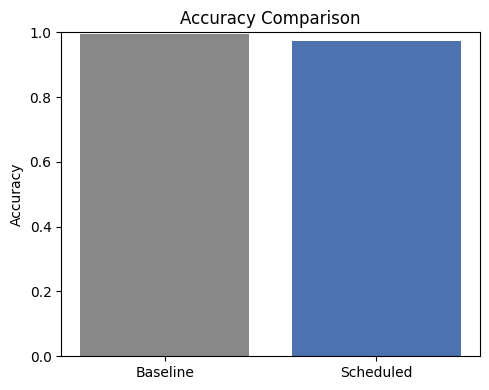

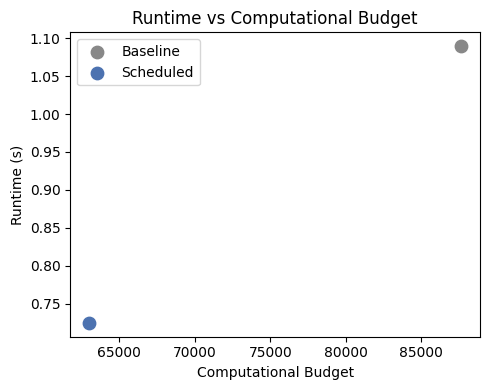

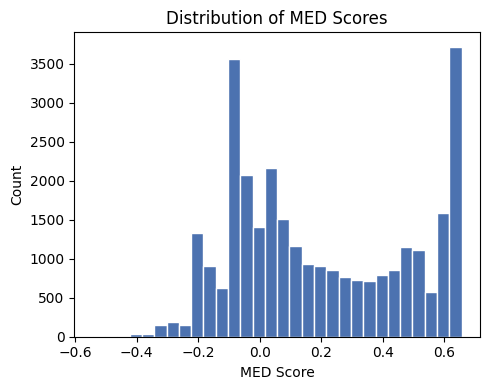

In [10]:
# Small graph, dense SBM, proportional budget (0.10 * n_nodes) -- the
# original V0 default. Budget drops to ~70% of baseline here, but runtime
# does NOT beat baseline at this scale: the local subgraph trick isn't
# actually local when the selected count scales with n. Accuracy is now
# measured on held-out test nodes (60/20/20 train/val/test split), so it
# reflects generalization rather than in-sample fit.
results_small = run_v0_experiments()


## Large-graph run (sparse SBM, absolute selection budget)

This is the regime where the scheduled model's runtime actually beats the
deep baseline while spending less compute -- see the notebook discussion.
Slower than the small run above (~1-2 min depending on hardware).


=== Run 1/5 (seed=0) ===

--- Baseline GCN ---
Accuracy:             0.7462
Precision (macro):    0.7492
Recall (macro):       0.7483
F1 (macro):           0.7460
Runtime (s):          5.0334
Total Budget:         720000.0
Avg Budget/Node:      180.0000
Scheduler Efficiency: 0.000001

--- Scheduled GCN ---
Accuracy:             0.5975
Precision (macro):    0.6005
Recall (macro):       0.5990
F1 (macro):           0.5972
Runtime (s):          0.8021
Total Budget:         481770.0
Avg Budget/Node:      120.4425
Scheduler Efficiency: 0.000001

=== Run 2/5 (seed=1) ===

--- Baseline GCN ---
Accuracy:             0.6450
Precision (macro):    0.6457
Recall (macro):       0.6441
F1 (macro):           0.6404
Runtime (s):          1.9640
Total Budget:         720000.0
Avg Budget/Node:      180.0000
Scheduler Efficiency: 0.000001

--- Scheduled GCN ---
Accuracy:             0.5550
Precision (macro):    0.5548
Recall (macro):       0.5551
F1 (macro):           0.5533
Runtime (s):          0.8511

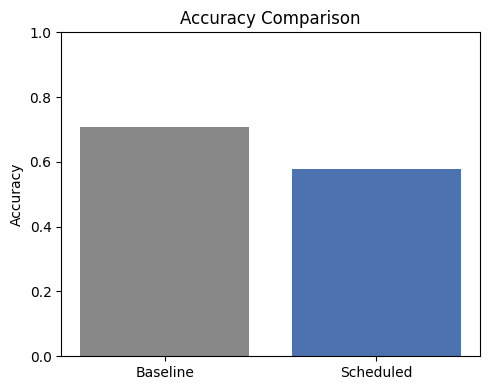

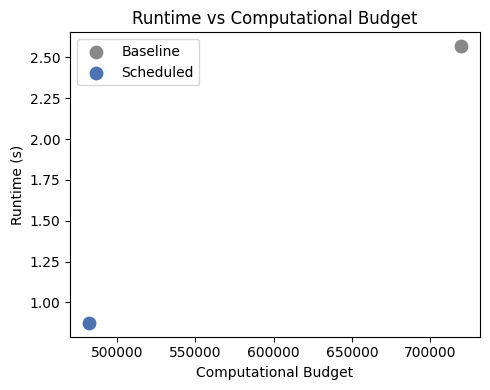

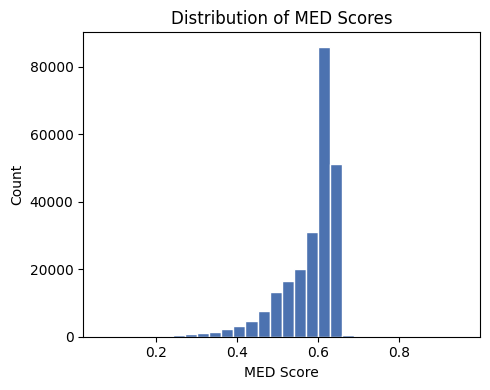

In [11]:
results_large = run_v0_experiments(
    n_nodes=4000, epochs=60, avg_degree=15, budget_count=30,
)


---

# Version 1 — Large-Scale Batch Study

150 total runs (50 small / 50 medium / 50 large), each producing a
baseline + scheduled pair on the same graph. Saves results in batches of
10, one combined CSV, five summary figures, and three hypothesis tests.

**Nothing in `data.py`/`model.py`/`scheduler.py`/`experiment.py` changes
here** -- this reuses `generate_sbm_graph`, `train_baseline`, and
`train_scheduled` exactly as validated in Version 0. Only the run
orchestration, plotting, and statistics are new.

**"Medium" is newly introduced here** (not part of V0): n=1500, sparse
SBM (avg_degree=25), absolute budget_count=50, 50 epochs -- a config
already explored during V0 discussion, sitting between the easy small
case and the hard large case. Flagging this explicitly since it's a new
assumption, not something previously fixed.

## `batch_runner.py` — 150-run orchestration with incremental batch saving

In [12]:
import pandas as pd
import os
from scipy.stats import skew

V1_OUTPUT_DIR = "gnn_v1_results"
V1_BATCH_DIR = os.path.join(V1_OUTPUT_DIR, "batches")
V1_FIGURE_DIR = os.path.join(V1_OUTPUT_DIR, "figures")

# Config per graph size. "small" and "large" match the exact V0 configs
# already validated; "medium" is newly chosen (see markdown above).
SIZE_CONFIGS = {
    "small": dict(
        n_nodes=300, epochs=100, avg_degree=None,
        budget_fraction=0.10, budget_count=None,
        p_intra=0.15, p_inter=0.02,
    ),
    "medium": dict(
        n_nodes=1500, epochs=50, avg_degree=25,
        budget_fraction=0.10, budget_count=50,
        p_intra=0.15, p_inter=0.02,
    ),
    "large": dict(
        n_nodes=4000, epochs=60, avg_degree=15,
        budget_fraction=0.10, budget_count=30,
        p_intra=0.15, p_inter=0.02,
    ),
}

RUNS_PER_SIZE = 50
BATCH_SIZE = 10  # runs per batch (each run = 1 baseline row + 1 scheduled row)


def _run_one(size_name, seed):
    """
    Run baseline + scheduled once on the SAME fresh graph. Returns the two
    row-dicts for the master CSV, plus per-node correctness arrays (used
    only for the McNemar accuracy test, not persisted to the CSV -- they'd
    bloat it well beyond "one CSV of 150 results").
    """
    cfg = SIZE_CONFIGS[size_name]

    data = generate_sbm_graph(
        n_nodes=cfg["n_nodes"], n_communities=3,
        p_intra=cfg["p_intra"], p_inter=cfg["p_inter"],
        avg_degree=cfg["avg_degree"], seed=seed,
    )

    base = train_baseline(data, hidden_dim=32, epochs=cfg["epochs"], lr=0.01, seed=seed)
    sched = train_scheduled(
        data, hidden_dim=32, epochs=cfg["epochs"], lr=0.01, seed=seed,
        budget_fraction=cfg["budget_fraction"], budget_count=cfg["budget_count"],
        reconsider_every=5,
    )

    base_metrics = compute_classification_metrics(base["preds"], base["y"])
    sched_metrics = compute_classification_metrics(sched["preds"], sched["y"])

    # Same data object, same test_mask, same node order for both calls --
    # these two boolean arrays are properly paired node-for-node.
    base_correct = (base["preds"] == base["y"]).numpy()
    sched_correct = (sched["preds"] == sched["y"]).numpy()

    all_med = np.concatenate(sched["med_history"]) if sched["med_history"] else np.array([np.nan])
    med_mean = float(np.nanmean(all_med))
    med_skew = float(skew(all_med)) if len(all_med) > 1 else float("nan")

    base_row = dict(
        size=size_name, seed=seed, model="baseline",
        accuracy=base_metrics["accuracy"], precision=base_metrics["precision"],
        recall=base_metrics["recall"], f1=base_metrics["f1"],
        runtime=base["runtime"], total_budget=base["total_budget"],
        avg_budget_per_node=base["avg_budget_per_node"],
        scheduler_efficiency=scheduler_efficiency(base_metrics["accuracy"], base["total_budget"]),
        med_mean=float("nan"), med_skew=float("nan"),  # MED is undefined for baseline
    )
    sched_row = dict(
        size=size_name, seed=seed, model="scheduled",
        accuracy=sched_metrics["accuracy"], precision=sched_metrics["precision"],
        recall=sched_metrics["recall"], f1=sched_metrics["f1"],
        runtime=sched["runtime"], total_budget=sched["total_budget"],
        avg_budget_per_node=sched["avg_budget_per_node"],
        scheduler_efficiency=scheduler_efficiency(sched_metrics["accuracy"], sched["total_budget"]),
        med_mean=med_mean, med_skew=med_skew,
    )

    return base_row, sched_row, base_correct, sched_correct


def run_v1_study(runs_per_size=RUNS_PER_SIZE, batch_size=BATCH_SIZE, verbose=True):
    """
    Runs `runs_per_size` seeds for each of small/medium/large, saves
    results in batches of `batch_size` runs (one CSV per batch, per size --
    e.g. batch_small_01.csv .. batch_small_05.csv for 50 runs / batch 10),
    and returns one combined DataFrame covering all runs plus the raw
    counts needed for the McNemar accuracy test.
    """
    os.makedirs(V1_BATCH_DIR, exist_ok=True)

    all_rows = []
    mcnemar_b = 0  # baseline correct, scheduled wrong
    mcnemar_c = 0  # baseline wrong, scheduled correct

    for size_name in ["small", "medium", "large"]:
        batch_rows = []
        batch_num = 0

        for i in range(runs_per_size):
            seed = i
            base_row, sched_row, base_correct, sched_correct = _run_one(size_name, seed)

            mcnemar_b += int((base_correct & ~sched_correct).sum())
            mcnemar_c += int((~base_correct & sched_correct).sum())

            batch_rows.append(base_row)
            batch_rows.append(sched_row)
            all_rows.append(base_row)
            all_rows.append(sched_row)

            if (i + 1) % batch_size == 0 or (i + 1) == runs_per_size:
                batch_num += 1
                batch_df = pd.DataFrame(batch_rows)
                batch_path = os.path.join(V1_BATCH_DIR, f"batch_{size_name}_{batch_num:02d}.csv")
                batch_df.to_csv(batch_path, index=False)
                batch_rows = []

                if verbose:
                    print(f"[{size_name}] {i+1}/{runs_per_size} runs done -- saved {batch_path}")

    full_df = pd.DataFrame(all_rows)
    full_path = os.path.join(V1_OUTPUT_DIR, "all_results.csv")
    full_df.to_csv(full_path, index=False)

    print(f"\nSaved {len(full_df)} rows ({len(full_df)//2} runs) to {full_path}")

    return full_df, dict(mcnemar_b=mcnemar_b, mcnemar_c=mcnemar_c)


## `plots_v1.py` — Five summary figures

Each figure is one PNG with two side-by-side panels:
- **Left ("All Runs")**: every individual run's value, split ONLY by
  model (baseline vs scheduled), pooled across all three graph sizes.
- **Right ("Aggregates by Size")**: mean (+/- std) per group, split by
  BOTH graph size (small/medium/large) AND model.

MED is the one exception: it's undefined for the baseline model (only
the scheduled model produces MED scores), so its figure only ever shows
a "Scheduled" series -- there is no baseline comparison to draw.

In [13]:
def _plot_full_and_aggregate(df, metric_col, title, ylabel, filename, med_mode=False):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ---------------- LEFT: all runs, split by model only ----------------
    ax = axes[0]
    sub = df.dropna(subset=[metric_col])

    if med_mode:
        data_to_plot = [sub[sub["model"] == "scheduled"][metric_col].values]
        labels = ["Scheduled"]
        colors = ["#4C72B0"]
    else:
        data_to_plot = [
            sub[sub["model"] == "baseline"][metric_col].values,
            sub[sub["model"] == "scheduled"][metric_col].values,
        ]
        labels = ["Baseline", "Scheduled"]
        colors = ["#888888", "#4C72B0"]

    bp = ax.boxplot(data_to_plot, tick_labels=labels, showfliers=False, patch_artist=True)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)

    rng = np.random.default_rng(0)
    for i, vals in enumerate(data_to_plot):
        x_jitter = rng.normal(loc=i + 1, scale=0.05, size=len(vals))
        ax.scatter(x_jitter, vals, alpha=0.35, s=12, color=colors[i], edgecolor="none")

    ax.set_title("All Runs")
    ax.set_ylabel(ylabel)

    # ---------------- RIGHT: aggregates by size, split by model ----------------
    ax2 = axes[1]
    sizes = ["small", "medium", "large"]
    x = np.arange(len(sizes))
    width = 0.35

    if med_mode:
        sched_means = [sub[(sub["size"] == s) & (sub["model"] == "scheduled")][metric_col].mean() for s in sizes]
        sched_stds = [sub[(sub["size"] == s) & (sub["model"] == "scheduled")][metric_col].std() for s in sizes]
        ax2.bar(x, sched_means, width, yerr=sched_stds, label="Scheduled", color="#4C72B0", capsize=4)
    else:
        base_means = [sub[(sub["size"] == s) & (sub["model"] == "baseline")][metric_col].mean() for s in sizes]
        base_stds = [sub[(sub["size"] == s) & (sub["model"] == "baseline")][metric_col].std() for s in sizes]
        sched_means = [sub[(sub["size"] == s) & (sub["model"] == "scheduled")][metric_col].mean() for s in sizes]
        sched_stds = [sub[(sub["size"] == s) & (sub["model"] == "scheduled")][metric_col].std() for s in sizes]

        ax2.bar(x - width / 2, base_means, width, yerr=base_stds, label="Baseline", color="#888888", capsize=4)
        ax2.bar(x + width / 2, sched_means, width, yerr=sched_stds, label="Scheduled", color="#4C72B0", capsize=4)

    ax2.set_xticks(x)
    ax2.set_xticklabels([s.capitalize() for s in sizes])
    ax2.set_title("Aggregates by Graph Size")
    ax2.legend()

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    os.makedirs(V1_FIGURE_DIR, exist_ok=True)
    path = os.path.join(V1_FIGURE_DIR, filename)
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")


def _plot_interaction_figure(df):
    """
    Budget-vs-Accuracy tradeoff -- the central question of this whole
    project -- with Runtime encoded as marker size and graph size encoded
    as marker shape. MED is deliberately NOT included here: it has no
    baseline counterpart, which would make overlaying it on a
    baseline-vs-scheduled comparison plot misleading rather than
    informative.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    size_markers = {"small": "o", "medium": "s", "large": "^"}
    model_colors = {"baseline": "#888888", "scheduled": "#4C72B0"}

    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=model_colors["baseline"], markersize=8, label="Baseline"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=model_colors["scheduled"], markersize=8, label="Scheduled"),
        Line2D([0], [0], marker="o", color="gray", linestyle="None", markersize=6, label="Small"),
        Line2D([0], [0], marker="s", color="gray", linestyle="None", markersize=6, label="Medium"),
        Line2D([0], [0], marker="^", color="gray", linestyle="None", markersize=6, label="Large"),
    ]

    # ---------------- LEFT: all individual runs ----------------
    ax = axes[0]
    for model in ["baseline", "scheduled"]:
        for size_name in ["small", "medium", "large"]:
            sub = df[(df["model"] == model) & (df["size"] == size_name)]
            ax.scatter(
                sub["total_budget"], sub["accuracy"],
                s=sub["runtime"] * 15 + 10,
                marker=size_markers[size_name],
                color=model_colors[model],
                alpha=0.5, edgecolor="white", linewidth=0.3,
            )
    ax.legend(handles=legend_elems, fontsize=8, loc="best")
    ax.set_xlabel("Total Budget")
    ax.set_ylabel("Accuracy")
    ax.set_title("All Runs (marker size = runtime)")

    # ---------------- RIGHT: aggregates ----------------
    ax2 = axes[1]
    for model in ["baseline", "scheduled"]:
        for size_name in ["small", "medium", "large"]:
            sub = df[(df["model"] == model) & (df["size"] == size_name)]
            bx, by = sub["total_budget"].mean(), sub["accuracy"].mean()
            bxerr, byerr = sub["total_budget"].std(), sub["accuracy"].std()
            brt = sub["runtime"].mean()
            ax2.errorbar(
                bx, by, xerr=bxerr, yerr=byerr,
                marker=size_markers[size_name], color=model_colors[model],
                markersize=brt * 3 + 6, alpha=0.8, capsize=3, linestyle="None",
            )
    ax2.legend(handles=legend_elems, fontsize=8, loc="best")
    ax2.set_xlabel("Mean Total Budget")
    ax2.set_ylabel("Mean Accuracy")
    ax2.set_title("Aggregates by Size (marker size = mean runtime)")

    fig.suptitle("Budget vs Accuracy Tradeoff (Runtime as Marker Size)", fontsize=14)
    plt.tight_layout()
    os.makedirs(V1_FIGURE_DIR, exist_ok=True)
    path = os.path.join(V1_FIGURE_DIR, "5_interaction.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")


def generate_v1_figures(df):
    _plot_full_and_aggregate(df, "accuracy", "Accuracy: Baseline vs Scheduled", "Accuracy", "1_accuracy.png")
    _plot_full_and_aggregate(df, "total_budget", "Computational Budget: Baseline vs Scheduled", "Total Budget", "2_budget.png")
    _plot_full_and_aggregate(df, "runtime", "Runtime: Baseline vs Scheduled", "Runtime (s)", "3_runtime.png")
    _plot_full_and_aggregate(df, "med_mean", "Mean MED Score (Scheduled only -- undefined for baseline)", "Mean MED", "4_med.png", med_mode=True)
    _plot_interaction_figure(df)


## `stats_v1.py` — Summary statistics + three hypothesis tests

1. **Runtime** -- paired t-test (H1: scheduled < baseline). Paired because
   each run's baseline and scheduled model trained on the SAME graph/seed.
2. **Budget** -- paired t-test (H1: scheduled < baseline). Same reasoning.
3. **Accuracy** -- McNemar's test (chi-squared, 1 df), not a t-test. This
   is deliberate: accuracy here comes from per-node correct/incorrect
   outcomes, and baseline and scheduled are evaluated on the exact same
   test nodes in every run -- so this is a paired BINARY comparison, not
   two independent continuous samples. McNemar's test is the standard,
   correct chi-squared-family test for exactly this situation (it IS a
   chi-squared statistic under the hood), which is why a plain t-test on
   run-level accuracy isn't the right tool here.

In [14]:
from scipy.stats import ttest_rel, chi2


def compute_v1_statistics(df, mcnemar_counts):
    print("=" * 70)
    print("SUMMARY STATISTICS (grouped by size x model)")
    print("=" * 70)

    summary = df.groupby(["size", "model"])[
        ["accuracy", "precision", "recall", "f1", "runtime",
         "total_budget", "avg_budget_per_node", "scheduler_efficiency"]
    ].agg(["mean", "std", "min", "max", "median"])

    print(summary)

    summary_path = os.path.join(V1_OUTPUT_DIR, "summary_statistics.csv")
    summary.to_csv(summary_path)
    print(f"\nSaved summary statistics to {summary_path}")

    print("\n" + "=" * 70)
    print("HYPOTHESIS TESTS")
    print("=" * 70)

    # Pivot so each run's baseline/scheduled values sit side by side --
    # required for a properly PAIRED test.
    pivot = df.pivot_table(index=["size", "seed"], columns="model",
                           values=["runtime", "total_budget"])

    # ---- Test 1: Runtime ----
    rt_base = pivot[("runtime", "baseline")].values
    rt_sched = pivot[("runtime", "scheduled")].values
    t_rt, p_two_rt = ttest_rel(rt_base, rt_sched)
    p_one_rt = p_two_rt / 2 if t_rt > 0 else 1 - p_two_rt / 2
    print(f"\n1) Runtime -- paired t-test, H1: scheduled < baseline")
    print(f"   mean baseline={rt_base.mean():.4f}s | mean scheduled={rt_sched.mean():.4f}s")
    print(f"   t={t_rt:.3f}, one-sided p={p_one_rt:.6g}")

    # ---- Test 2: Budget ----
    bg_base = pivot[("total_budget", "baseline")].values
    bg_sched = pivot[("total_budget", "scheduled")].values
    t_bg, p_two_bg = ttest_rel(bg_base, bg_sched)
    p_one_bg = p_two_bg / 2 if t_bg > 0 else 1 - p_two_bg / 2
    print(f"\n2) Budget -- paired t-test, H1: scheduled < baseline")
    print(f"   mean baseline={bg_base.mean():.1f} | mean scheduled={bg_sched.mean():.1f}")
    print(f"   t={t_bg:.3f}, one-sided p={p_one_bg:.6g}")

    # ---- Test 3: Accuracy (McNemar, chi-squared) ----
    b, c = mcnemar_counts["mcnemar_b"], mcnemar_counts["mcnemar_c"]
    if b + c == 0:
        stat_mc, p_mc = 0.0, 1.0
    else:
        stat_mc = (abs(b - c) - 1) ** 2 / (b + c)  # continuity-corrected
        p_mc = chi2.sf(stat_mc, df=1)
    print(f"\n3) Accuracy -- McNemar's test (chi-squared, 1 df)")
    print(f"   baseline-correct/scheduled-wrong (b) = {b}")
    print(f"   baseline-wrong/scheduled-correct (c) = {c}")
    print(f"   chi2={stat_mc:.3f}, p={p_mc:.6g}")
    if b + c > 0:
        direction = "baseline outperforms more often" if b > c else "scheduled outperforms more often"
        print(f"   ({direction} on discordant node-level predictions)")

    return summary


## Run the V1 study

150 runs total (50 per size x baseline+scheduled = 300 training calls).
Expect this to take several minutes -- large-graph runs are the slowest
(the earlier 50-run large-only test took a few minutes on its own).

Everything is saved under `gnn_v1_results/`:
- `batches/batch_<size>_<01-05>.csv` -- 15 incremental batch files
- `all_results.csv` -- one combined CSV, all 300 rows
- `summary_statistics.csv`
- `figures/1_accuracy.png` .. `figures/5_interaction.png`

In [15]:
df_v1, mcnemar_counts = run_v1_study()


[small] 10/50 runs done -- saved gnn_v1_results/batches/batch_small_01.csv
[small] 20/50 runs done -- saved gnn_v1_results/batches/batch_small_02.csv
[small] 30/50 runs done -- saved gnn_v1_results/batches/batch_small_03.csv
[small] 40/50 runs done -- saved gnn_v1_results/batches/batch_small_04.csv
[small] 50/50 runs done -- saved gnn_v1_results/batches/batch_small_05.csv
[medium] 10/50 runs done -- saved gnn_v1_results/batches/batch_medium_01.csv
[medium] 20/50 runs done -- saved gnn_v1_results/batches/batch_medium_02.csv
[medium] 30/50 runs done -- saved gnn_v1_results/batches/batch_medium_03.csv
[medium] 40/50 runs done -- saved gnn_v1_results/batches/batch_medium_04.csv
[medium] 50/50 runs done -- saved gnn_v1_results/batches/batch_medium_05.csv
[large] 10/50 runs done -- saved gnn_v1_results/batches/batch_large_01.csv
[large] 20/50 runs done -- saved gnn_v1_results/batches/batch_large_02.csv
[large] 30/50 runs done -- saved gnn_v1_results/batches/batch_large_03.csv
[large] 40/50 r

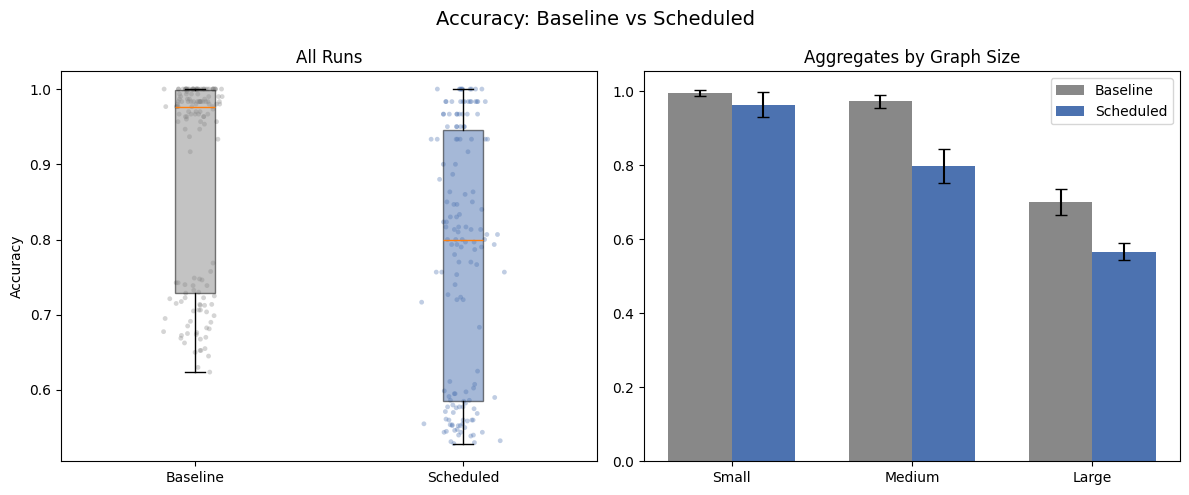

Saved: gnn_v1_results/figures/1_accuracy.png


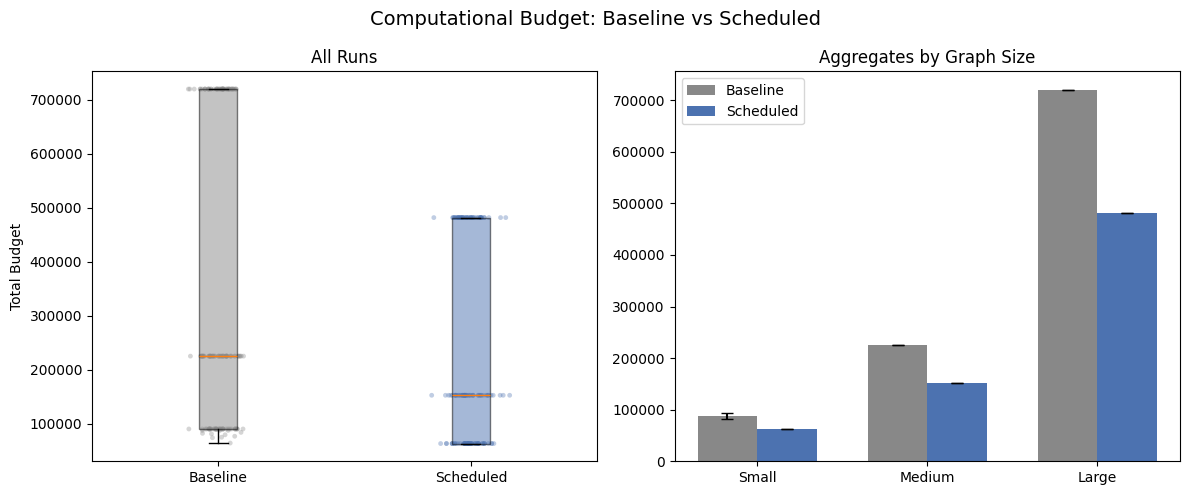

Saved: gnn_v1_results/figures/2_budget.png


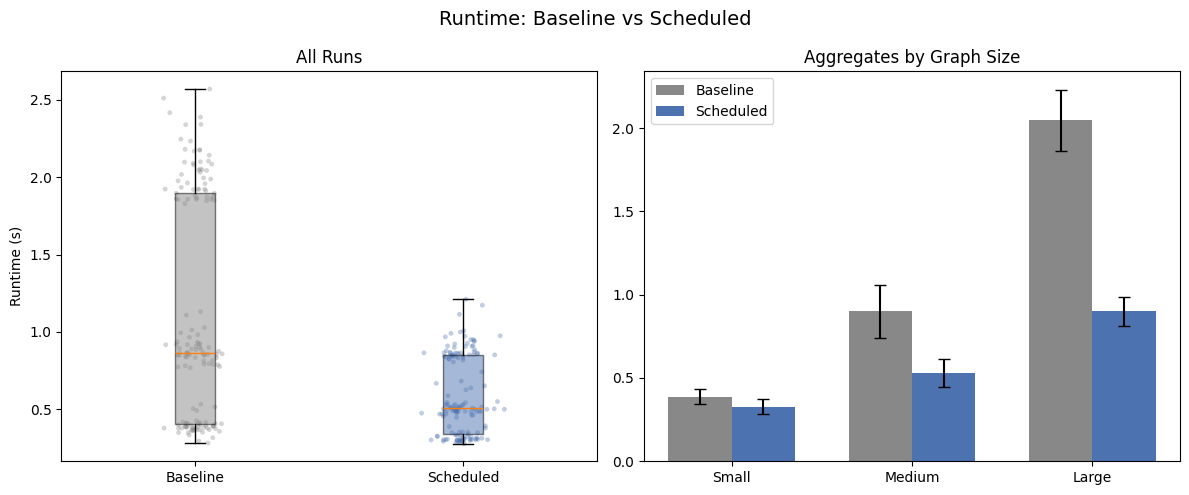

Saved: gnn_v1_results/figures/3_runtime.png


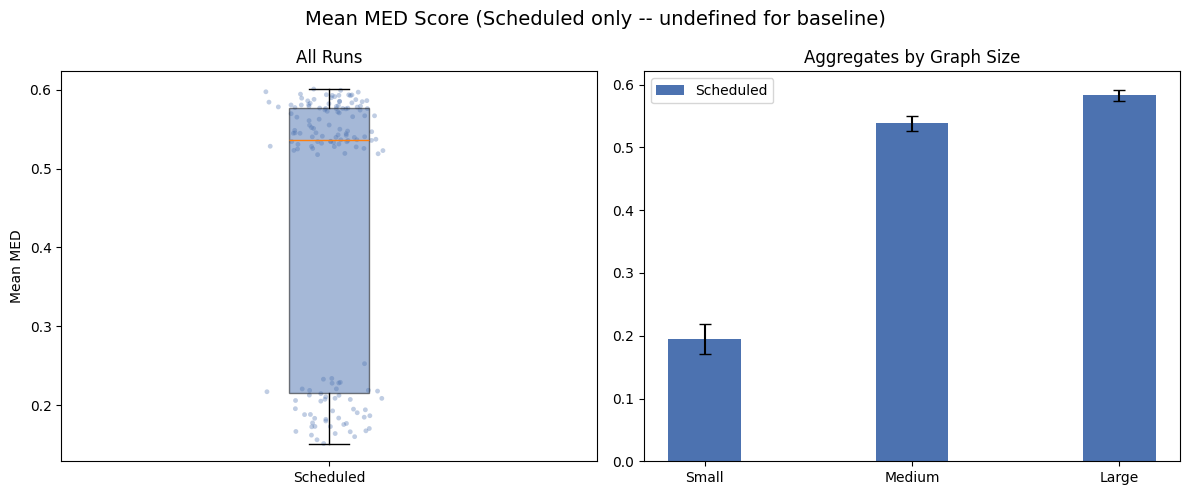

Saved: gnn_v1_results/figures/4_med.png


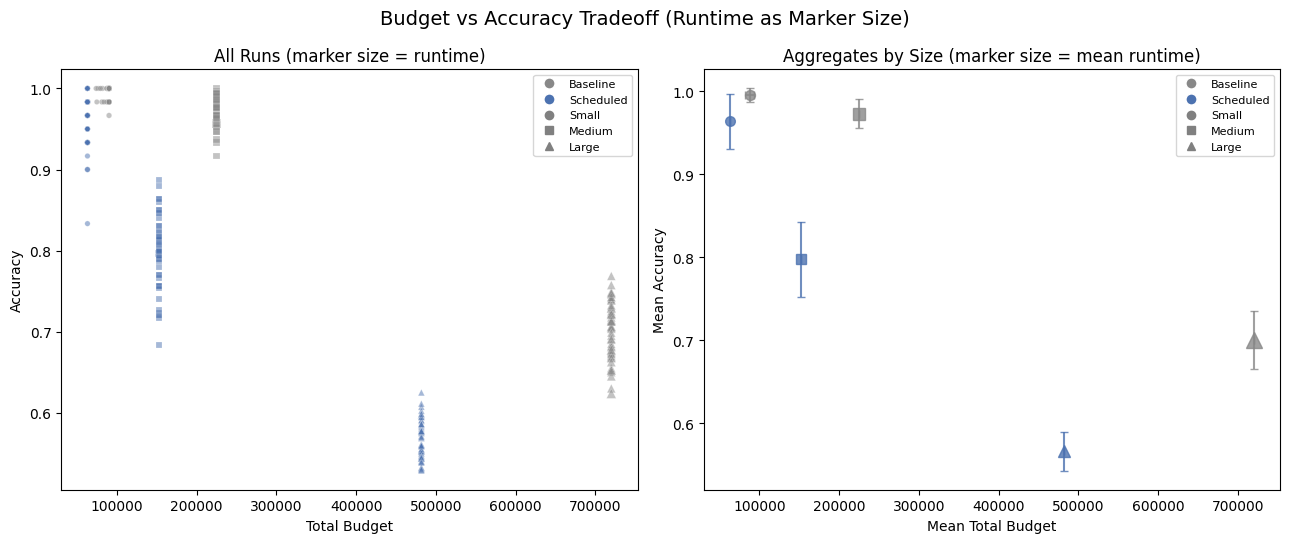

Saved: gnn_v1_results/figures/5_interaction.png


In [16]:
generate_v1_figures(df_v1)


In [17]:
summary_v1 = compute_v1_statistics(df_v1, mcnemar_counts)


SUMMARY STATISTICS (grouped by size x model)
                  accuracy                                         precision  \
                      mean       std       min       max    median      mean   
size   model                                                                   
large  baseline   0.700725  0.035152  0.623750  0.768750  0.705625  0.702529   
       scheduled  0.566475  0.023537  0.528750  0.625000  0.560000  0.566965   
medium baseline   0.973067  0.017416  0.916667  1.000000  0.976667  0.973767   
       scheduled  0.797733  0.045298  0.683333  0.886667  0.800000  0.798004   
small  baseline   0.995333  0.008275  0.966667  1.000000  1.000000  0.995746   
       scheduled  0.964000  0.033224  0.833333  1.000000  0.966667  0.964780   

                                                          ...  \
                       std       min       max    median  ...   
size   model                                              ...   
large  baseline   0.035591  0.624210  0

## Optional: zip and download all V1 results

Only relevant if you're running this in actual Google Colab (not needed
if running locally -- the files are already on disk under
`gnn_v1_results/`).

In [18]:
import shutil

zip_path = shutil.make_archive("gnn_v1_results", "zip", V1_OUTPUT_DIR)
print(f"Zipped results to {zip_path}")

try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("Not running in Google Colab -- skip the download step, "
          "the zip file is already saved locally.")


Zipped results to /content/gnn_v1_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>